In [1]:
import os
from typing import List, Dict, Tuple, Optional
import requests
import logging
import urllib
import json
import time
from datetime import datetime
import numpy as np 
import csv
import re
import random
import matplotlib.pyplot as plt
import pandas as pd 
from tqdm.notebook import tqdm
from eutils import EutilsNCBIError, EutilsRequestError
import seaborn as sns




In [2]:
data = pd.read_csv("/var/storage/naji/NCBI_data_20251129.csv")
print(data.head)


<bound method NDFrame.head of              PMID        PMCID  \
0         8278517    PMC160626   
1        11791906          NaN   
2        15923308          NaN   
3        18852454   PMC2570983   
4        31897883   PMC7851104   
...           ...          ...   
1150271  12093728    PMC125393   
1150272  25884789   PMC4431298   
1150273  30288888          NaN   
1150274  36915825  PMC10006533   
1150275  25136126   PMC4156734   

                                                     Title  \
0        Nucleotide sequence of the psaE gene of cyanob...   
1        Effects of bone cement extracts on the cell-me...   
2        Estrogen regulates beta1-subunit expression in...   
3        Evolution of the ssrA degradation tag in Mycop...   
4        Hypoxia preconditioning protects neuronal cell...   
...                                                    ...   
1150271  FXYD7 is a brain-specific regulator of Na,K-AT...   
1150272  A homogenous fluorescence quenching based assa...   
115

In [3]:
Publishers_list = data["Publisher"].unique()


In [4]:
data['year'] = data['Date of Publication'].str[:4]
data['year'] = data['year'].astype(int)

In [5]:
wiley_count = data["Publisher"].str.contains("Wiley", case=False, na=False).sum()
print(wiley_count)


119122


In [6]:
elsevier_count = data["Publisher"].str.contains("Elsevier", case=False, na=False).sum()
print(elsevier_count)

293451


In [7]:
wiley_count1 = (data["Publisher"] == "Wiley (John Wiley & Sons)").sum()
print(wiley_count1)


68205


In [8]:
data.loc[data["Publisher"].str.contains("Wiley", case=False, na=False), "Publisher"] = "Wiley"
data.loc[data["Publisher"].str.contains("Elsevier", case=False, na=False), "Publisher"] = "Elsevier"
data.loc[data["Publisher"].str.contains("MDPI", case=False, na=False), "Publisher"] = "MDPI"
data.loc[data["Publisher"].str.contains("Springer", case=False, na=False), "Publisher"] = "Springer"
data.loc[data["Publisher"].str.contains("Proceedings of the National Academy of Sciences", case=False, na=False), "Publisher"] = "PNAS"
data.loc[data["Publisher"].str.contains("Informa UK", case=False, na=False), "Publisher"] = "Informa UK"
data.loc[data["Publisher"].str.contains("Hindawi", case=False, na=False), "Publisher"] = "Hindawi"
data.loc[data["Publisher"].str.contains("Baishideng Publishing Group Co", case=False, na=False), "Publisher"] = "Baishideng Publishing Group Co"
data.loc[data["Publisher"].str.contains("Wolters Kluwer", case=False, na=False), "Publisher"] = "Wolters Kluwer"

In [ ]:
print(data.head)

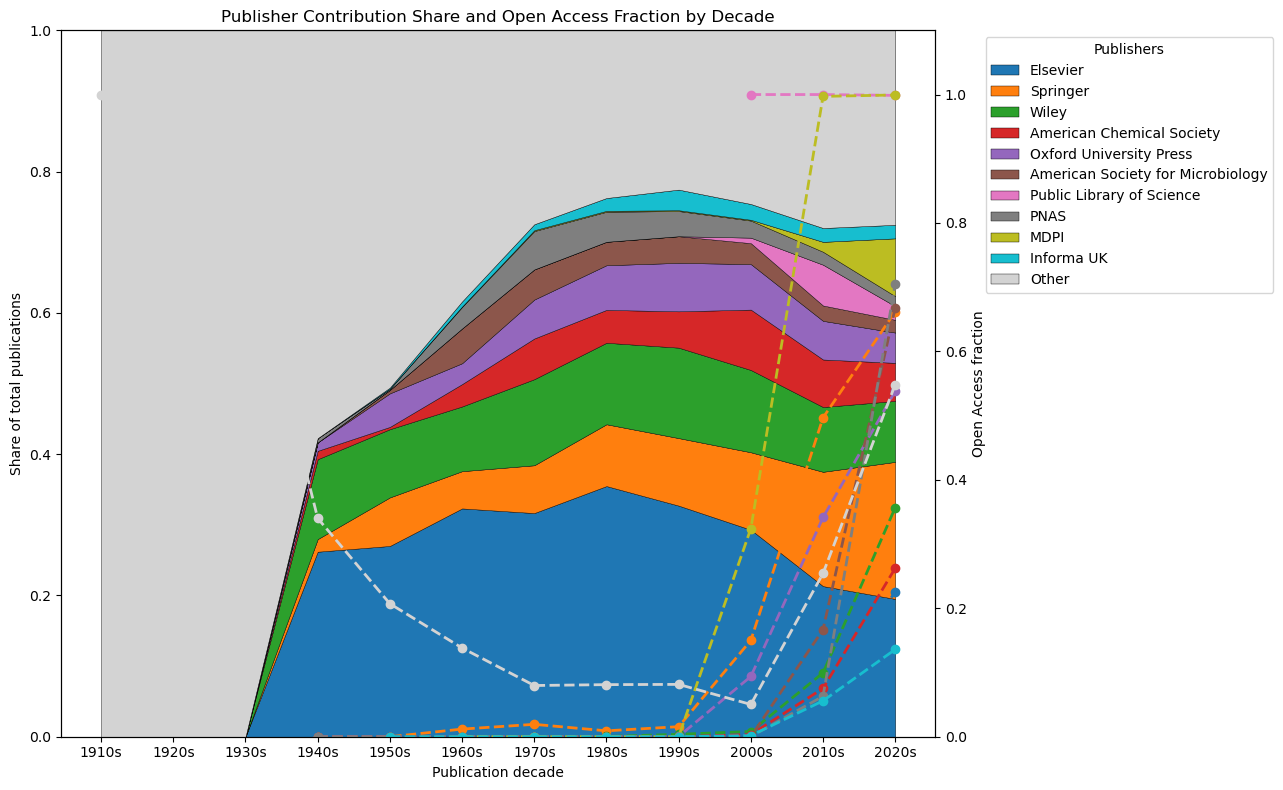

In [9]:
# Prepare data

data["is_oa"] = data["OA-noncomm"].astype(int)
data["decade"] = (data["year"] // 10) * 10


# Top 10 publishers
top10 = data["Publisher"].value_counts().nlargest(10).index

data["publisher_grouped"] = data["Publisher"].where(
    data["Publisher"].isin(top10),
    "Other"
)
#aggregate

grouped = (
    data.groupby(["decade","publisher_grouped"])
    .agg(
        total_papers=("Publisher","size"),
        oa_papers=("is_oa","sum")
    )
    .reset_index()
)

grouped["oa_fraction"] = grouped["oa_papers"] / grouped["total_papers"]

#pivot tables


pivot_total = grouped.pivot(
    index="decade",
    columns="publisher_grouped",
    values="total_papers"
).fillna(0)

pivot_oa = grouped.pivot(
    index="decade",
    columns="publisher_grouped",
    values="oa_fraction"
)

#fixed order
publisher_order = list(top10) + ["Other"]

pivot_total = pivot_total[publisher_order]
pivot_oa = pivot_oa[publisher_order]

#farction of total publications per decade

pivot_share = pivot_total.div(pivot_total.sum(axis=1), axis=0)

# Colors pallete

palette = sns.color_palette("tab10", 10)
publisher_colors = dict(zip(top10, palette))
publisher_colors["Other"] = "lightgray"

# make 2 axes

fig, ax1 = plt.subplots(figsize=(13, 8))
ax2 = ax1.twinx()

#stacked plot
x_vals = pivot_share.index
y_vals = [pivot_share[p].values for p in publisher_order]

ax1.stackplot(
    x_vals,
    *y_vals,
    labels=publisher_order,
    colors=[publisher_colors[p] for p in publisher_order],
    edgecolor="black",
    linewidth=0.3
)

ax1.set_ylabel("Share of total publications")
ax1.set_ylim(0, 1)

# dashed OA lines
for publisher in publisher_order:
    ax2.plot(
        pivot_oa.index,
        pivot_oa[publisher],
        marker="o",
        linestyle="--",
        color=publisher_colors[publisher],
        linewidth=2,
        # no label to avoid duplicate legend entries
    )

ax2.set_ylabel("Open Access fraction")
ax2.set_ylim(0, 1.1)

# xaxis formatting 
ax1.set_xlabel("Publication decade")
ax1.set_xticks(pivot_share.index)
ax1.set_xticklabels([f"{d}s" for d in pivot_share.index])

# title and legend  
ax1.set_title("Publisher Contribution Share and Open Access Fraction by Decade")

# Place legend for publishers
ax1.legend(
    title="Publishers",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

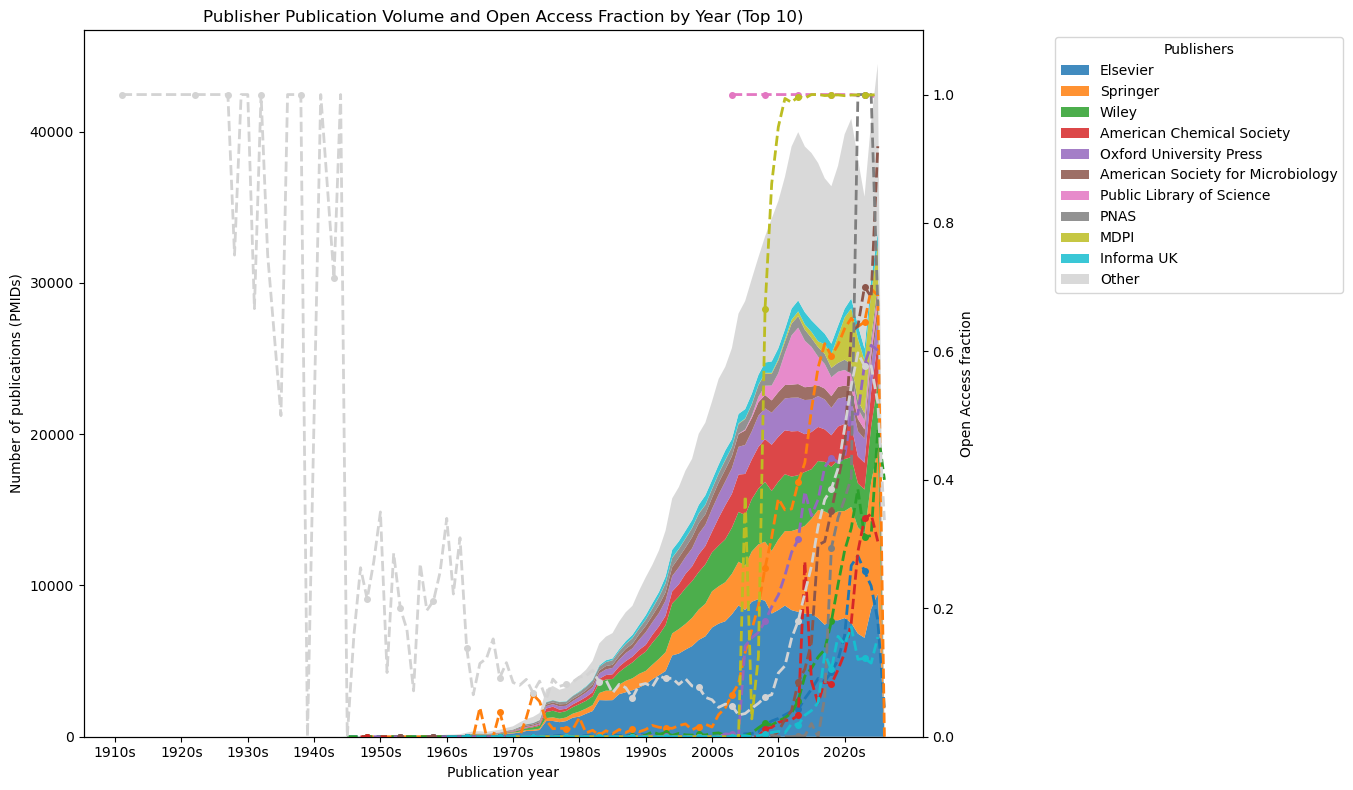

In [10]:
# Prepare data

data["is_oa"] = data["OA-noncomm"].astype(int)


# Top 10 publishers

top10 = data["Publisher"].value_counts().nlargest(10).index

data["publisher_grouped"] = data["Publisher"].where(
    data["Publisher"].isin(top10),
    "Other"
)


# aggregate by year
grouped = (
    data.groupby(["year", "publisher_grouped"])
    .agg(
        total_papers=("Publisher", "size"),
        oa_papers=("is_oa", "sum")
    )
    .reset_index()
)

grouped["oa_fraction"] = grouped["oa_papers"] / grouped["total_papers"]


#oivot tables

pivot_total = grouped.pivot(
    index="year",
    columns="publisher_grouped",
    values="total_papers"
).fillna(0)

pivot_oa = grouped.pivot(
    index="year",
    columns="publisher_grouped",
    values="oa_fraction"
)

# fixed order
publisher_order = list(top10) + ["Other"]
pivot_total = pivot_total[publisher_order]
pivot_oa    = pivot_oa[publisher_order]


# colors pallete

palette = sns.color_palette("tab10", 10)
publisher_colors = dict(zip(top10, palette))
publisher_colors["Other"] = "lightgray"
colors = [publisher_colors[p] for p in publisher_order]


#figure 2 axes

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

years = pivot_total.index

#Stacked area
ax1.stackplot(
    years,
    [pivot_total[p].values for p in publisher_order],
    labels=publisher_order,
    colors=colors,
    alpha=0.85
)

ax1.set_ylabel("Number of publications (PMIDs)")
ax1.set_ylim(0)

#OA fraction lines
for publisher in publisher_order:
    ax2.plot(
        pivot_oa.index,
        pivot_oa[publisher],
        linestyle="--",
        marker="o",
        markevery=5,
        color=publisher_colors[publisher],
        linewidth=2,
        markersize=4
    )

ax2.set_ylabel("Open Access fraction")
ax2.set_ylim(0, 1.1)

#xaxis years
tick_years = np.arange((years.min() // 10) * 10, (years.max() // 10) * 10 + 1, 10)
ax1.set_xlabel("Publication year")
ax1.set_xticks(tick_years)
ax1.set_xticklabels([f"{y}s" for y in tick_years])

#title and legend
ax1.set_title("Publisher Publication Volume and Open Access Fraction by Year (Top 10)")

ax1.legend(
    title="Publishers",
    bbox_to_anchor=(1.15, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [11]:
data = data[data['year'] != 2026]


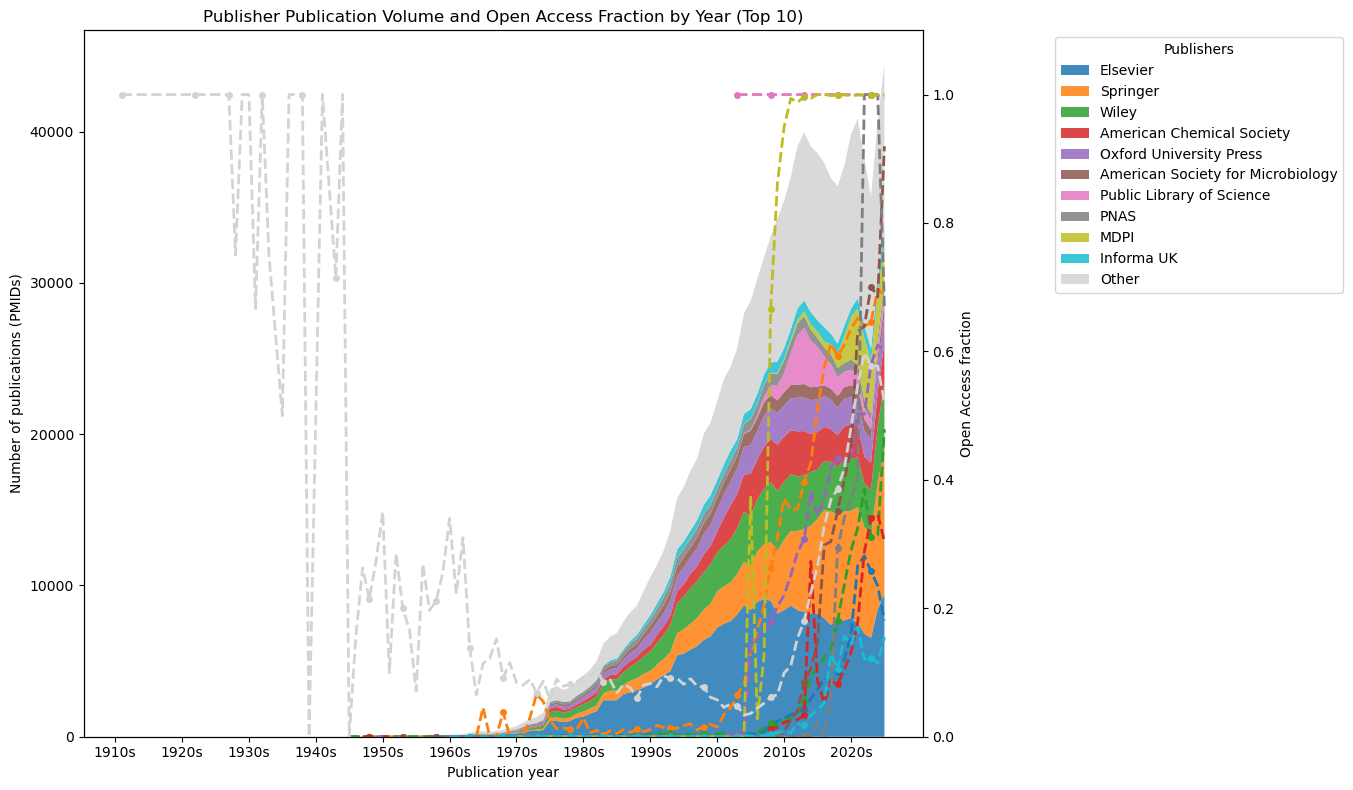

In [12]:
# Prepare data

data["is_oa"] = data["OA-noncomm"].astype(int)


# Top 10 publishers

top10 = data["Publisher"].value_counts().nlargest(10).index

data["publisher_grouped"] = data["Publisher"].where(
    data["Publisher"].isin(top10),
    "Other"
)


# aggregate by year
grouped = (
    data.groupby(["year", "publisher_grouped"])
    .agg(
        total_papers=("Publisher", "size"),
        oa_papers=("is_oa", "sum")
    )
    .reset_index()
)

grouped["oa_fraction"] = grouped["oa_papers"] / grouped["total_papers"]


#oivot tables

pivot_total = grouped.pivot(
    index="year",
    columns="publisher_grouped",
    values="total_papers"
).fillna(0)

pivot_oa = grouped.pivot(
    index="year",
    columns="publisher_grouped",
    values="oa_fraction"
)

# fixed order
publisher_order = list(top10) + ["Other"]
pivot_total = pivot_total[publisher_order]
pivot_oa    = pivot_oa[publisher_order]


# colors pallete

palette = sns.color_palette("tab10", 10)
publisher_colors = dict(zip(top10, palette))
publisher_colors["Other"] = "lightgray"
colors = [publisher_colors[p] for p in publisher_order]


#figure 2 axes

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

years = pivot_total.index

#Stacked area
ax1.stackplot(
    years,
    [pivot_total[p].values for p in publisher_order],
    labels=publisher_order,
    colors=colors,
    alpha=0.85
)

ax1.set_ylabel("Number of publications (PMIDs)")
ax1.set_ylim(0)

#OA fraction lines
for publisher in publisher_order:
    ax2.plot(
        pivot_oa.index,
        pivot_oa[publisher],
        linestyle="--",
        marker="o",
        markevery=5,
        color=publisher_colors[publisher],
        linewidth=2,
        markersize=4
    )

ax2.set_ylabel("Open Access fraction")
ax2.set_ylim(0, 1.1)

#xaxis years
tick_years = np.arange((years.min() // 10) * 10, (years.max() // 10) * 10 + 1, 10)
ax1.set_xlabel("Publication year")
ax1.set_xticks(tick_years)
ax1.set_xticklabels([f"{y}s" for y in tick_years])

#title and legend
ax1.set_title("Publisher Publication Volume and Open Access Fraction by Year (Top 10)")

ax1.legend(
    title="Publishers",
    bbox_to_anchor=(1.15, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()
